# Puget Sound Hypoxia Analysis
This notebook consolidates all key plots including vertical profiles, DO distributions, lagged correlations, and hypoxia severity metrics.

Data Processing and Calculations: 
These cells include the full data extraction and time series aggregation used prior to plotting.

In [ ]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arrow
import os
from scipy.stats import pearsonr, linregress
from collections import defaultdict
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
import seaborn as sns

# -----------------------------
# OUTPUT
# -----------------------------
output_dir = "generated_figures_NewBathyHC"
os.makedirs(output_dir, exist_ok=True)

def save_fig(fig, name):
    fig.savefig(os.path.join(output_dir, f"{name}.png"), dpi=300, bbox_inches='tight')
    plt.close(fig)

# Dataset paths
DATASETS = {
    "base": (
        '/ocean/atall/MOAD/Model/202410b/oxygen/',
        '/ocean/atall/MOAD/grid/mesh_mask_202310b.nc'
    ),
    "newbathy": (
        '/ocean/atall/MOAD/Model/202410b_NewBathyHC/',
        '/ocean/atall/MOAD/grid/mesh_mask202604.nc'
    )
}

START_YEAR = 2015
END_YEAR = 2015

# REGIONS - ONLY LYNCH COVE - New Bathy analysis focuses on this region, so we can ignore the others for this analysis
REGIONS = {
    'Lynch Cove': (129, 140, 67, 76),
}

STRAT_DEPTHS = {
    'Lynch Cove': {'surface': (0, 10), 'bottom': (20, 50)},
}

HYPOXIA_THRESHOLD = 63.0

# STORAGE 
def nested_list():
    return defaultdict(lambda: defaultdict(list))

def nested_year_float():
    return defaultdict(lambda: defaultdict(lambda: defaultdict(float)))

def nested_year_int():
    return defaultdict(lambda: defaultdict(lambda: defaultdict(int)))

def nested_year_inf():
    return defaultdict(lambda: defaultdict(lambda: defaultdict(lambda: np.inf)))

ts_DO_profiles = nested_list()
ts_temp_profiles = nested_list()
ts_salt_profiles = nested_list()

ts_temp = nested_list()
ts_salt = nested_list()

all_DO = nested_list()

annual_hypoxic_days = nested_year_int()
annual_hypoxic_volume = nested_year_float()
normalized_hypoxic_volume = nested_year_float()

annual_min_DO = nested_year_inf()
annual_min_DO_coords = nested_year_float()
annual_min_DO_temp = nested_year_float()
annual_min_DO_salt = nested_year_float()

daily_min_DO_series = nested_list()
daily_min_temp_series = nested_list()
daily_min_salt_series = nested_list()

annual_mean_temp = nested_year_float()
annual_mean_salt = nested_year_float()
annual_day_counts = nested_year_int()

dates = []


In [ ]:
def get_file_path(base_dir, date_obj, file_type):
    yr2 = date_obj.strftime("%y")
    Month = date_obj.strftime("%b").lower()
    day_num = date_obj.day
    year = date_obj.year
    month = date_obj.month

    if file_type == 'chem': suffix = '_chem_T.nc'
    elif file_type == 'grid': suffix = '_grid_T.nc'

    fname = f'SalishSea_1d_{year}{month:02}{day_num:02}_{year}{month:02}{day_num:02}{suffix}'
    fpath = os.path.join(base_dir, f"{day_num:02}{Month}{yr2}", fname)
    return fpath


In [10]:
print("Starting data processing...")

start_date = arrow.get(START_YEAR, 1, 2) # Start from Jan 2 (for the new bathy run, Jan 1 is missing)
end_date   = arrow.get(END_YEAR, 12, 31)

for dataset_name, (DATA_DIR, MESH_FILE) in DATASETS.items():

    print(f"Processing {dataset_name}...")

    # Load mesh per dataset
    with xr.open_dataset(MESH_FILE) as mesh:

        depth_array = mesh['gdept_0'][0].values
        depth_array_1d = mesh['gdept_0'][0, :, 0, 0].values

        e1t = mesh['e1t'][0, :, :]
        e2t = mesh['e2t'][0, :, :]
        e3t = mesh['e3t_0'][0, :, :, :]
        tmask = mesh['tmask'][0, :, :, :]

        vol_cell = e1t * e2t
        vol_3d = (e3t * vol_cell) * tmask
        vol_3d = vol_3d.values  

    # Time loop
    for day in arrow.Arrow.range('day', start_date, end_date):

        fchem = get_file_path(DATA_DIR, day, 'chem')
        fgrid = get_file_path(DATA_DIR, day, 'grid')

        if not (os.path.exists(fchem) and os.path.exists(fgrid)):
            continue

        with xr.open_dataset(fchem) as ds_chem, xr.open_dataset(fgrid) as ds_grid:

            for region, (ii1, ii2, jj1, jj2) in REGIONS.items():

                # ---- DO ----
                DO = ds_chem['dissolved_oxygen'][0, :, jj1:jj2, ii1:ii2]
                DO = xr.where(DO == 0, np.nan, DO)

                DO_profile = DO.mean(dim=['y', 'x'], skipna=True).values
                ts_DO_profiles[dataset_name][region].append((day.datetime, DO_profile))
                all_DO[dataset_name][region].append(DO.values.flatten())

                # TEMP / SALT 
                temp = ds_grid['votemper'][0, :, jj1:jj2, ii1:ii2]
                temp = xr.where(temp == 0, np.nan, temp)

                salt = ds_grid['vosaline'][0, :, jj1:jj2, ii1:ii2]
                salt = xr.where(salt == 0, np.nan, salt)

                temp_profile = temp.mean(dim=['y', 'x'], skipna=True).values
                salt_profile = salt.mean(dim=['y', 'x'], skipna=True).values

                ts_temp_profiles[dataset_name][region].append((day.datetime, temp_profile))
                ts_salt_profiles[dataset_name][region].append((day.datetime, salt_profile))

                mean_temp = float(np.nanmean(temp))
                mean_salt = float(np.nanmean(salt))

                ts_temp[dataset_name][region].append((day.datetime, mean_temp))
                ts_salt[dataset_name][region].append((day.datetime, mean_salt))

                # HYPOXIA
                hypoxic_mask = DO < HYPOXIA_THRESHOLD

                region_vol = vol_3d[:, jj1:jj2, ii1:ii2]
                total_region_volume = region_vol.sum()
                hypoxic_volume = (hypoxic_mask * region_vol).sum()

                if hypoxic_volume > 0:
                    year = day.year
                    annual_hypoxic_days[dataset_name][region][year] += 1
                    annual_hypoxic_volume[dataset_name][region][year] += hypoxic_volume
                    normalized_hypoxic_volume[dataset_name][region][year] += (
                        hypoxic_volume / total_region_volume
                    )

                # MIN DO 
                if np.isnan(DO.values).all():
                    continue

                daily_min_do = np.nanmin(DO.values)
                idx_min = np.unravel_index(np.nanargmin(DO.values), DO.shape)
                d_idx, y_idx, x_idx = idx_min

                year = day.year

                if daily_min_do < annual_min_DO[dataset_name][region][year]:
                    annual_min_DO[dataset_name][region][year] = daily_min_do
                    annual_min_DO_coords[dataset_name][region][year] = idx_min
                    annual_min_DO_temp[dataset_name][region][year] = temp.values[d_idx, y_idx, x_idx]
                    annual_min_DO_salt[dataset_name][region][year] = salt.values[d_idx, y_idx, x_idx]

                # DAILY SERIES
                daily_min_DO_series[dataset_name][region].append((day.datetime, daily_min_do))
                daily_min_temp_series[dataset_name][region].append(
                    (day.datetime, temp.values[d_idx, y_idx, x_idx])
                )
                daily_min_salt_series[dataset_name][region].append(
                    (day.datetime, salt.values[d_idx, y_idx, x_idx])
                )

                # ANNUAL MEANS
                annual_mean_temp[dataset_name][region][year] += np.nanmean(temp)
                annual_mean_salt[dataset_name][region][year] += np.nanmean(salt)
                annual_day_counts[dataset_name][region][year] += 1

        dates.append(day.datetime)

print("Finished data processing.")

Starting data processing...
Processing base...
Processing newbathy...
Finished data processing.


### FIGURES

In [24]:
unitO = 'DO (mmol m$^{-3}$)'
unitT = 'Temperature (°C)'
unitS = 'Salinity (g kg$^{-1}$)'
depth_array_1d = mesh['gdept_0'][0].mean(dim=['y','x'], skipna=True).values


Vertical Profiles: DO, Temperature, Salinity

/tmp/ipykernel_168685/622651268.py:26: RuntimeWarning: Mean of empty slice
  mean_profile = np.nanmean(profiles, axis=0)
/tmp/ipykernel_168685/622651268.py:26: RuntimeWarning: Mean of empty slice
  mean_profile = np.nanmean(profiles, axis=0)
/tmp/ipykernel_168685/622651268.py:26: RuntimeWarning: Mean of empty slice
  mean_profile = np.nanmean(profiles, axis=0)
/tmp/ipykernel_168685/622651268.py:26: RuntimeWarning: Mean of empty slice
  mean_profile = np.nanmean(profiles, axis=0)
/tmp/ipykernel_168685/622651268.py:26: RuntimeWarning: Mean of empty slice
  mean_profile = np.nanmean(profiles, axis=0)
/tmp/ipykernel_168685/622651268.py:26: RuntimeWarning: Mean of empty slice
  mean_profile = np.nanmean(profiles, axis=0)


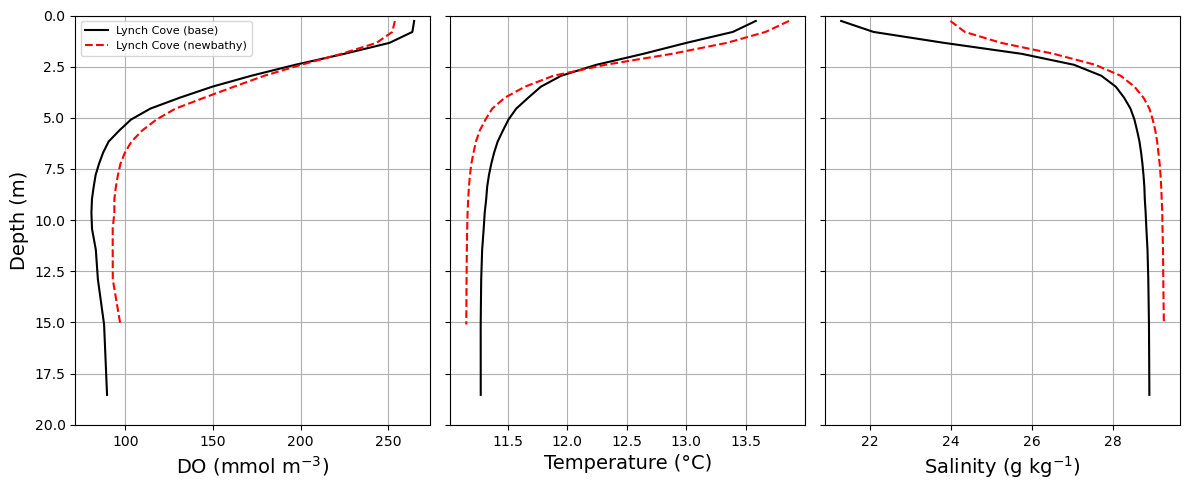

In [28]:
fig, ax = plt.subplots(1, 3, figsize=(12, 5), sharey=True)

titles = ['Dissolved Oxygen', 'Temperature', 'Salinity']
units = [unitO, unitT, unitS]
profile_dicts = [ts_DO_profiles, ts_temp_profiles, ts_salt_profiles]

colors = {
    "base": "black",
    "newbathy": "red"
}

for i, (title, unit, ts_profiles) in enumerate(zip(titles, units, profile_dicts)):

    for dataset in DATASETS.keys():
        for region in REGIONS.keys():

            profiles = [
                xr.where(prof == 0, np.nan, prof)
                for _, prof in ts_profiles[dataset][region]
            ]

            if len(profiles) == 0:
                continue

            profiles = np.array(profiles)
            mean_profile = np.nanmean(profiles, axis=0)

            label = f"{region} ({dataset})"
            ax[i].plot(mean_profile, depth_array_1d,
                       label=label,
                       color=colors[dataset],
                       linestyle='-' if dataset == "base" else '--')

    ax[i].invert_yaxis()
    ax[i].set_ylim(20, 0)
    ax[i].set_xlabel(unit, fontsize=14)
    ax[i].grid(True)

ax[0].set_ylabel('Depth (m)', fontsize=14)
ax[0].legend(fontsize=8)

plt.tight_layout()
plt.show()
save_fig(fig, "mean_profiles_comparison")

Plot distribution of DO concentrations (PDFs)

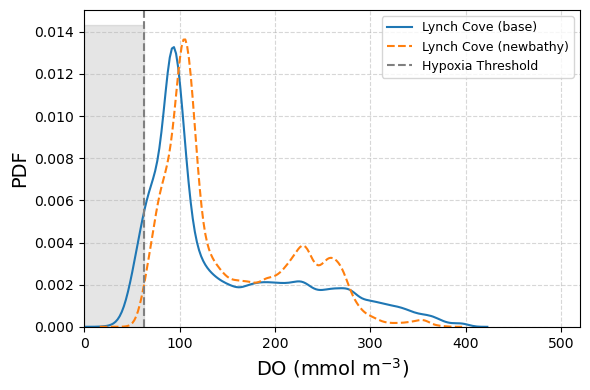

In [30]:
fig, ax = plt.subplots(figsize=(6, 4))

for dataset in DATASETS.keys():
    for region in REGIONS.keys():

        values_list = all_DO[dataset][region]

        if len(values_list) == 0:
            continue

        DO_values = np.concatenate(values_list)
        DO_values = DO_values[(~np.isnan(DO_values)) & (DO_values > 0)]

        label = f"{region} ({dataset})"

        sns.kdeplot(
            DO_values,
            label=label,
            linestyle='-' if dataset == "base" else '--'
        )

ax.axvline(63, color='gray', linestyle='--', label='Hypoxia Threshold')
ax.fill_betweenx([0, ax.get_ylim()[1]], 0, 63, color='gray', alpha=0.2)

ax.set_xlabel(unitO, fontsize=14)
ax.set_ylabel("PDF", fontsize=14)
ax.set_xlim(0, 520)
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()
save_fig(fig, "DO_distribution_comparison")

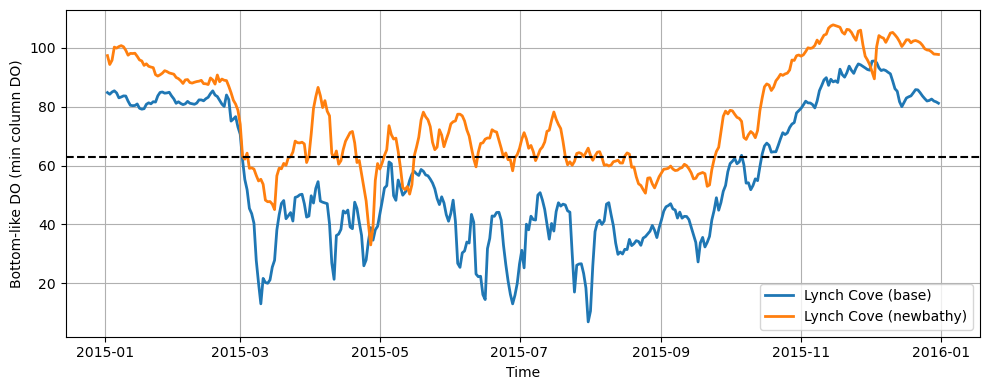

In [31]:
def extract_bottom_like_series(series, threshold):
    # series = [(time, value)]
    return [(t, v < threshold) for t, v in series]

fig, ax = plt.subplots(figsize=(10, 4))

for dataset in DATASETS:
    for region in REGIONS:

        series = daily_min_DO_series[dataset][region]
        if len(series) == 0:
            continue

        times, vals = zip(*series)

        vals = np.array(vals)

        ax.plot(times, vals,
                label=f"{region} ({dataset})",
                linewidth=2)

ax.axhline(HYPOXIA_THRESHOLD, color='black', linestyle='--')

ax.set_ylabel("Bottom-like DO (min column DO)")
ax.set_xlabel("Time")
ax.grid(True)
ax.legend()

plt.tight_layout()
plt.show()
save_fig(fig, "bottom_like_DO_timeseries")

In [35]:
DATASETS = {
    "base": (
        '/ocean/atall/MOAD/Model/202410b/oxygen/',
        '/ocean/atall/MOAD/grid/mesh_mask_202310b.nc'
    ),
    "newbathy": (
        '/ocean/atall/MOAD/Model/202410b_NewBathyHC/',
        '/ocean/atall/MOAD/grid/mesh_mask202604.nc'
    )
}
MESH_FILE_1 = '/ocean/atall/MOAD/grid/mesh_mask_202310b.nc'
MESH_FILE_2 = '/ocean/atall/MOAD/grid/mesh_mask202604.nc'

import numpy as np
import xarray as xr

def get_bathy_depth(mesh_file):

    mesh = xr.open_dataset(mesh_file)

    tmask = mesh["tmask"][0].values      # (z, y, x)
    gdept = mesh["gdept_0"][0].values    # (z, y, x)

    nz, ny, nx = tmask.shape

    bathy = np.full((ny, nx), np.nan)

    for j in range(ny):
        for i in range(nx):

            column = tmask[:, j, i]

            if np.all(column == 0):
                continue  # land point

            k = np.where(column == 1)[0][-1]  # last wet level

            bathy[j, i] = gdept[k, j, i]

    return bathy

bathy_base = get_bathy_depth(MESH_FILE_1)
bathy_new  = get_bathy_depth(MESH_FILE_2)

In [38]:
for region, (ii1, ii2, jj1, jj2) in REGIONS.items():

    base_mean = np.nanmean(bathy_base[jj1:jj2, ii1:ii2])
    new_mean  = np.nanmean(bathy_new[jj1:jj2, ii1:ii2])

    print(region)
    print("  base mean depth:", base_mean)
    print("  new  mean depth:", new_mean)
    print("  Δ depth:", new_mean - base_mean)

Lynch Cove
  base mean depth: 17.860168075561525
  new  mean depth: 18.233289845784505
  Δ depth: 0.3731217702229799


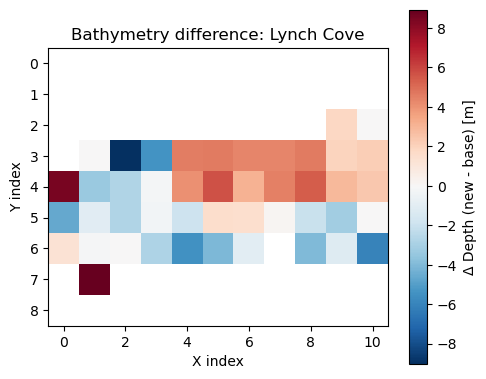

In [41]:
bathy_diff = bathy_new - bathy_base

for region, (ii1, ii2, jj1, jj2) in REGIONS.items():

    diff_reg = bathy_diff[jj1:jj2, ii1:ii2]

    fig, ax = plt.subplots(figsize=(5, 4))

    im = ax.imshow(diff_reg, cmap="RdBu_r")

    plt.colorbar(im, ax=ax, label="Δ Depth (new - base) [m]")

    ax.set_title(f"Bathymetry difference: {region}")

    ax.set_xlabel("X index")
    ax.set_ylabel("Y index")

    plt.tight_layout()
    plt.show()

### Save results in .csv

In [ ]:
#Save daily min DO, temp, salt, remin, do2 for all regions
for var_name, series_dict in [
    ('daily_min_DO', daily_min_DO_series),
    ('daily_min_temp', daily_min_temp_series),
    ('daily_min_salt', daily_min_salt_series),
]:
    df = pd.DataFrame({
        region: pd.Series(dict(data))
        for region, data in series_dict.items()
    })
    df.index.name = 'date'
    df.to_csv(f'{var_name}_timeseries.csv')

#Convert nested dict to DataFrame
def nested_dict_to_df(nested_dict):
    return pd.DataFrame(nested_dict).sort_index()

nested_dict_to_df(annual_mean_temp).to_csv("annual_mean_temp.csv")
nested_dict_to_df(annual_mean_salt).to_csv("annual_mean_salt.csv")

nested_dict_to_df(annual_hypoxic_days).to_csv("annual_hypoxic_days.csv")
nested_dict_to_df(annual_hypoxic_volume).to_csv("annual_hypoxic_volume.csv")

# Flatten annual min DO-related data
for var_name, nested in [
    ('annual_min_DO', annual_min_DO),
    ('annual_min_DO_temp', annual_min_DO_temp),
    ('annual_min_DO_salt', annual_min_DO_salt),
]:
    df = pd.DataFrame(nested).sort_index()
    df.to_csv(f"{var_name}.csv")

# Save profiles
os.makedirs("daily_profiles_csv", exist_ok=True)
def save_profile_timeseries(ts_dict, var_name):
    for region, data in ts_dict.items():
        dates, profiles = zip(*data)  # Separate dates and vertical profile arrays
        df = pd.DataFrame(profiles, index=pd.to_datetime(dates))
        df.index.name = 'date'
        df.columns = [f"depth_{k}" for k in range(df.shape[1])]  # Optional: label columns
        out_path = f"daily_profiles_csv/{var_name}_{region}.csv"
        df.to_csv(out_path)

# Save each variable's profiles
save_profile_timeseries(ts_DO_profiles, "DO")
save_profile_timeseries(ts_temp_profiles, "temperature")
save_profile_timeseries(ts_salt_profiles, "salinity")
